In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup berhasil!")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Setup berhasil!
Pandas version: 3.0.3
NumPy version: 2.4.6


In [3]:
import pandas as pd          # library utama untuk olah data (seperti Excel tapi di Python)
import numpy as np           # library untuk operasi matematika & angka
import matplotlib.pyplot as plt  # library untuk bikin grafik/chart
import seaborn as sns        # library grafik yang lebih cantik, di atas matplotlib
from pandasql import sqldf   # supaya bisa nulis SQL query langsung ke DataFrame

plt.style.use('seaborn-v0_8-whitegrid')  # atur tampilan grafik jadi lebih bersih
pd.set_option('display.max_columns', None)  # tampilkan semua kolom, tidak dipotong

df = pd.read_csv('../data/creditcard.csv')  # baca file CSV dan simpan ke variabel df
# '../data/' artinya: mundur satu folder dari notebooks, masuk ke folder data
print("Shape:", df.shape)  # tampilkan jumlah baris dan kolom dataset
print("\n5 baris pertama:")
df.head()  # tampilkan 5 baris pertama untuk lihat struktur datanya

Shape: (284807, 31)

5 baris pertama:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# cek apakah ada nilai kosong/hilang di setiap kolom
# nilai kosong bisa bikin analisis kita salah kalau tidak ditangani
print("=== Missing Values ===")
print(df.isnull().sum())

# cek apakah ada baris yang duplikat persis sama
# data duplikat bisa bikin hasil analisis jadi bias
print("\n=== Duplikat ===")
print("Jumlah baris duplikat:", df.duplicated().sum())

# tampilkan info umum dataset: tipe data tiap kolom dan jumlah data tidak kosong
# pastikan semua kolom bertipe angka (float64/int64), bukan teks
print("\n=== Info Dataset ===")
df.info()

=== Missing Values ===
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

=== Duplikat ===
Jumlah baris duplikat: 1081

=== Info Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V

In [5]:
# hitung jumlah transaksi normal (0) dan fraud (1)
# Class = 0 artinya transaksi normal, Class = 1 artinya fraud
fraud_count = df['Class'].value_counts()

# hitung dalam persentase untuk lebih mudah dipahami
fraud_pct = df['Class'].value_counts(normalize=True) * 100
# normalize=True mengubah hitungan jadi proporsi (0-1), dikali 100 jadi persen

print("=== Jumlah Transaksi ===")
print(fraud_count)

print("\n=== Persentase ===")
print(fraud_pct.round(2))  # .round(2) supaya hanya tampil 2 angka di belakang koma

print("\n=== Rata-rata nilai transaksi ===")
print("Normal: $", df[df['Class']==0]['Amount'].mean().round(2))
# df[df['Class']==0] artinya: filter hanya baris yang Class-nya = 0
print("Fraud:  $", df[df['Class']==1]['Amount'].mean().round(2))

=== Jumlah Transaksi ===
Class
0    284315
1       492
Name: count, dtype: int64

=== Persentase ===
Class
0    99.83
1     0.17
Name: proportion, dtype: float64

=== Rata-rata nilai transaksi ===
Normal: $ 88.29
Fraud:  $ 122.21


In [6]:
# kolom Time berisi detik sejak transaksi pertama
# kita konversi ke jam supaya lebih mudah diinterpretasi
df['Hour'] = (df['Time'] / 3600).astype(int) % 24
# dibagi 3600 untuk convert detik ke jam
# % 24 supaya angkanya berputar 0-23 (format jam)

# bagi hari menjadi 4 periode waktu
df['Time_of_day'] = pd.cut(
    df['Hour'],
    bins=[0, 6, 12, 18, 24],        # batas-batas jamnya
    labels=['Dini hari', 'Pagi', 'Siang', 'Malam'],
    right=False                       # 0-5 = dini hari, 6-11 = pagi, dst
)

# hitung fraud rate per jam — jam berapa paling banyak fraud?
fraud_per_hour = df.groupby('Hour')['Class'].agg(['sum', 'count'])
# .agg(['sum','count']) = hitung jumlah fraud (sum) dan total transaksi (count) per jam
fraud_per_hour['fraud_rate'] = (fraud_per_hour['sum'] / fraud_per_hour['count'] * 100).round(3)
fraud_per_hour.columns = ['jumlah_fraud', 'total_transaksi', 'fraud_rate_%']

print("=== Fraud Rate per Jam (Top 5 paling berbahaya) ===")
print(fraud_per_hour.sort_values('fraud_rate_%', ascending=False).head())

=== Fraud Rate per Jam (Top 5 paling berbahaya) ===
      jumlah_fraud  total_transaksi  fraud_rate_%
Hour                                             
2               57             3328         1.713
4               23             2209         1.041
3               17             3492         0.487
5               11             2990         0.368
7               23             7243         0.318


In [7]:
pysqldf = lambda q: sqldf(q, globals())
# lambda di sini artinya kita bikin fungsi singkat bernama pysqldf
# globals() = kasih akses ke semua variabel yang ada, termasuk df kita

# query SQL persis seperti di database sungguhan
# bedanya tabel-nya adalah DataFrame pandas kita (df)
fraud_by_period = pysqldf("""
    SELECT 
        Time_of_day,
        COUNT(*) AS total_transaksi,
        SUM(Class) AS jumlah_fraud,
        ROUND(100.0 * SUM(Class) / COUNT(*), 3) AS fraud_rate_pct
    FROM df
    GROUP BY Time_of_day
    ORDER BY fraud_rate_pct DESC
""")
# COUNT(*) = hitung semua baris per periode
# SUM(Class) = jumlahkan Class (karena fraud=1, ini otomatis hitung total fraud)
# ROUND(..., 3) = bulatkan ke 3 angka desimal

print("=== Fraud Rate per Periode Waktu ===")
print(fraud_by_period)

=== Fraud Rate per Periode Waktu ===
  Time_of_day  total_transaksi  jumlah_fraud  fraud_rate_pct
0   Dini hari            23934           124           0.518
1        Pagi            70912           118           0.166
2       Siang            96435           134           0.139
3       Malam            93526           116           0.124


Grafik tersimpan!


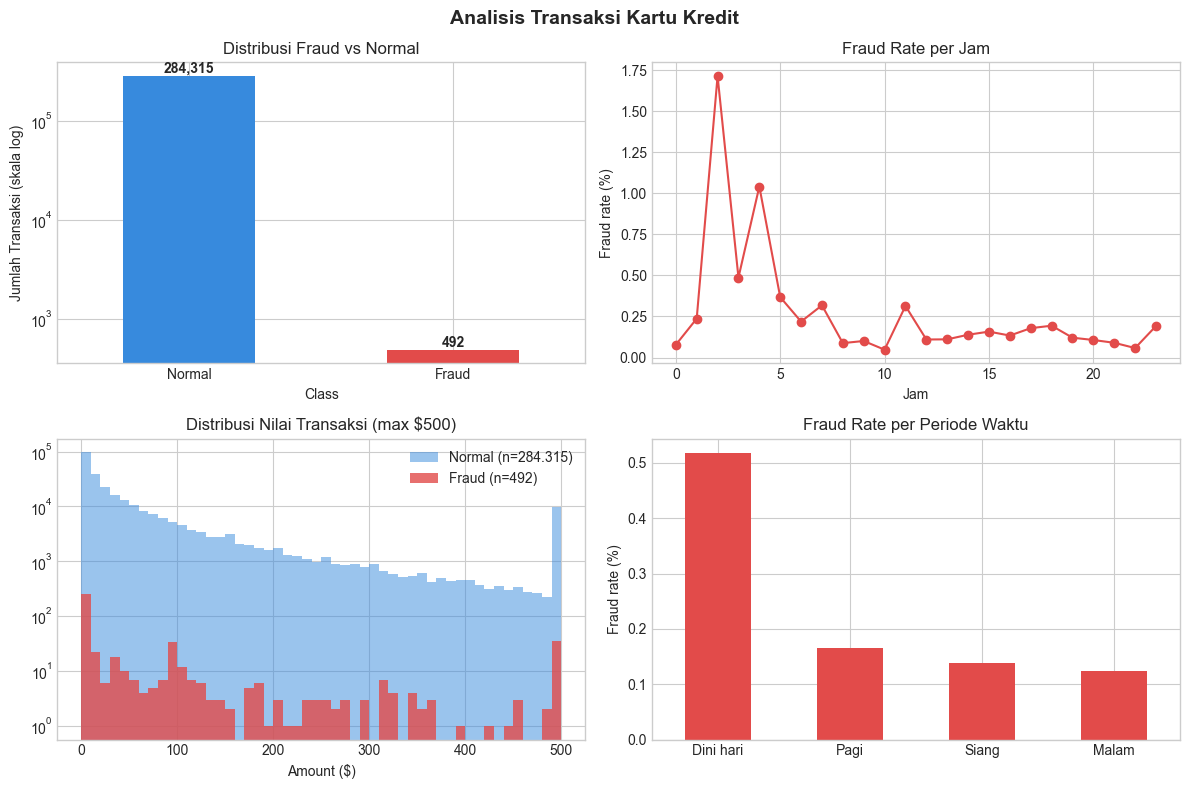

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Analisis Transaksi Kartu Kredit', fontsize=14, fontweight='bold')

# --- Grafik 1: pakai skala log supaya fraud keliatan ---
ax1 = axes[0, 0]
fraud_count.plot(kind='bar', ax=ax1, color=['#378ADD', '#E24B4A'])
ax1.set_title('Distribusi Fraud vs Normal')
ax1.set_xticklabels(['Normal', 'Fraud'], rotation=0)
ax1.set_ylabel('Jumlah Transaksi (skala log)')
ax1.set_yscale('log')
# set_yscale('log') = pakai skala logaritmik supaya nilai kecil tetap keliatan
for bar in ax1.patches:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{int(bar.get_height()):,}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
# kode di atas = tambah label angka di atas setiap batang

# --- Grafik 2: fraud rate per jam (tidak berubah) ---
ax2 = axes[0, 1]
fraud_per_hour['fraud_rate_%'].plot(ax=ax2, color='#E24B4A', marker='o')
ax2.set_title('Fraud Rate per Jam')
ax2.set_xlabel('Jam')
ax2.set_ylabel('Fraud rate (%)')

# --- Grafik 3: pisah jadi dua subplot supaya keduanya keliatan jelas ---
ax3 = axes[1, 0]
df_normal = df[df['Class']==0]['Amount'].clip(upper=500)
df_fraud = df[df['Class']==1]['Amount'].clip(upper=500)

ax3.hist(df_normal, bins=50, alpha=0.5, color='#378ADD', label=f'Normal (n=284.315)')
ax3.hist(df_fraud, bins=50, alpha=0.8, color='#E24B4A', label=f'Fraud (n=492)')
# alpha fraud dibuat lebih tinggi (0.8) supaya tidak tertutup warna biru
ax3.set_title('Distribusi Nilai Transaksi (max $500)')
ax3.set_xlabel('Amount ($)')
ax3.set_yscale('log')
# skala log lagi supaya fraud yang jumlahnya kecil tetap keliatan
ax3.legend()

# --- Grafik 4: fraud rate per periode (tidak berubah) ---
ax4 = axes[1, 1]
fraud_by_period.set_index('Time_of_day')['fraud_rate_pct'].plot(
    kind='bar', ax=ax4, color='#E24B4A')
ax4.set_title('Fraud Rate per Periode Waktu')
ax4.set_xlabel('')
ax4.set_ylabel('Fraud rate (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('../outputs/main_analysis.png', dpi=150, bbox_inches='tight')
print("Grafik tersimpan!")
plt.show()

## Temuan & Rekomendasi Bisnis

### Temuan Utama
1. **Dataset sangat imbalanced** — hanya 0.17% transaksi adalah fraud (492 dari 284.807)
2. **Dini hari paling berisiko** — fraud rate jam 02.00 mencapai 1.71%, hampir 10x rata-rata
3. **Nilai transaksi fraud lebih tinggi** — rata-rata $122 vs $88 untuk transaksi normal

### Rekomendasi
1. **Tingkatkan verifikasi OTP** pada transaksi yang terjadi pukul 00.00–06.00
2. **Flag otomatis** untuk transaksi di atas $100 yang terjadi dini hari
3. **Monitor real-time** lebih ketat di periode dini hari karena pengawasan manusia minimal

### Keterbatasan Analisis
- Fitur V1–V28 sudah di-PCA sehingga tidak bisa diinterpretasi langsung
- Dataset berasal dari tahun 2013, pola fraud mungkin sudah berubah

In [11]:
import subprocess
subprocess.run(['pip', 'freeze'], stdout=open('../requirements.txt', 'w'))
print("requirements.txt tersimpan!")

requirements.txt tersimpan!
